In [1]:
#Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
#Load dataset
column_names = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality"
]

df = pd.read_csv(
    "winequality-red-1.csv",
    sep=";",
    skiprows=1,
    names=column_names
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
#Dataset information
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000 

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


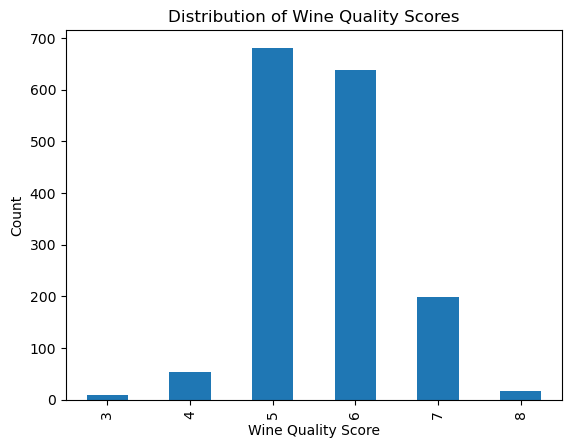

In [7]:
#Check original quality distribution

quality_counts = df["quality"].value_counts().sort_index()
print(quality_counts)

quality_counts.plot(kind="bar")
plt.xlabel("Wine Quality Score")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality Scores")
plt.show()

In [8]:
#Split features and target
X = df.drop(columns=["quality"])
y = df["quality"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Target classes:", sorted(y.unique()))

Feature shape: (1599, 11)
Target shape: (1599,)
Target classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [9]:
#Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (1279, 11)
Testing set: (320, 11)

Training target distribution:
quality
3    0.006255
4    0.032838
5    0.426114
6    0.398749
7    0.124316
8    0.011728
Name: proportion, dtype: float64

Testing target distribution:
quality
3    0.006250
4    0.034375
5    0.425000
6    0.400000
7    0.125000
8    0.009375
Name: proportion, dtype: float64


In [10]:
#Baseline Random Forest

rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

print("Baseline Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("Precision weighted:", precision_score(y_test, y_pred_base, average="weighted", zero_division=0))
print("Recall weighted:", recall_score(y_test, y_pred_base, average="weighted", zero_division=0))
print("F1-score weighted:", f1_score(y_test, y_pred_base, average="weighted", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, zero_division=0))

Baseline Random Forest Results
Accuracy: 0.678125
Precision weighted: 0.6530702552835941
Recall weighted: 0.678125
F1-score weighted: 0.6632452012467868

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320



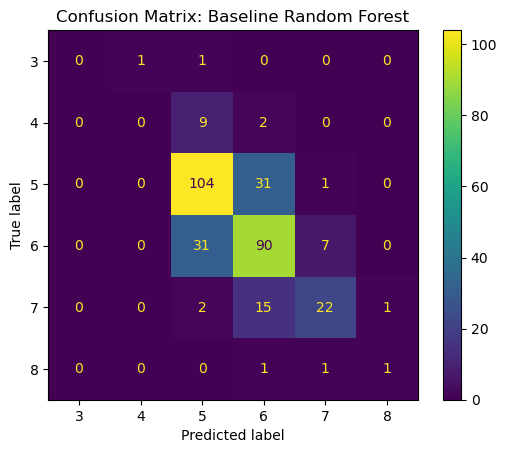

In [11]:
#Confusion matrix for baseline Random Forest

labels = sorted(y.unique())

cm_base = confusion_matrix(y_test, y_pred_base, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=labels
)

disp.plot()
plt.title("Confusion Matrix: Baseline Random Forest")
plt.show()

In [12]:
#Hyperparameter tuning

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation weighted F1 score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best cross-validation weighted F1 score:
0.6690865619125265


In [14]:
#Evaluate tuned Random Forest

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1-score (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0)
}

rf_results_df = pd.DataFrame([rf_results], index=["Tuned Random Forest"])
rf_results_df

,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
Tuned Random Forest,0.7,0.677735,0.7,0.684291


In [15]:
#Detailed classification report

print("Tuned Random Forest Classification Report")
print(classification_report(y_test, y_pred, zero_division=0))

Tuned Random Forest Classification Report
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.77      0.74       136
           6       0.66      0.73      0.70       128
           7       0.80      0.60      0.69        40
           8       1.00      0.33      0.50         3

    accuracy                           0.70       320
   macro avg       0.53      0.41      0.44       320
weighted avg       0.68      0.70      0.68       320



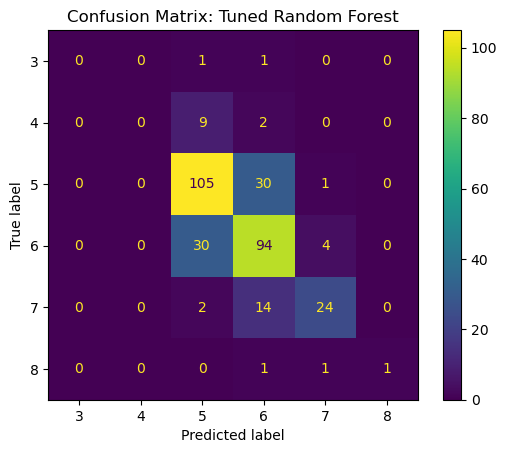

In [16]:
#Confusion matrix for tuned Random Forest

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Confusion Matrix: Tuned Random Forest")
plt.show()

In [18]:
#Compare baseline and tuned Random Forest

comparison_df = pd.DataFrame({
    "Baseline Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_base),
        "Precision (weighted)": precision_score(y_test, y_pred_base, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, y_pred_base, average="weighted", zero_division=0),
        "F1-score (weighted)": f1_score(y_test, y_pred_base, average="weighted", zero_division=0)
    },
    "Tuned Random Forest": rf_results
}).T

comparison_df

,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
Baseline Random Forest,0.678125,0.653070,0.678125,0.663245
Tuned Random Forest,0.700000,0.677735,0.700000,0.684291


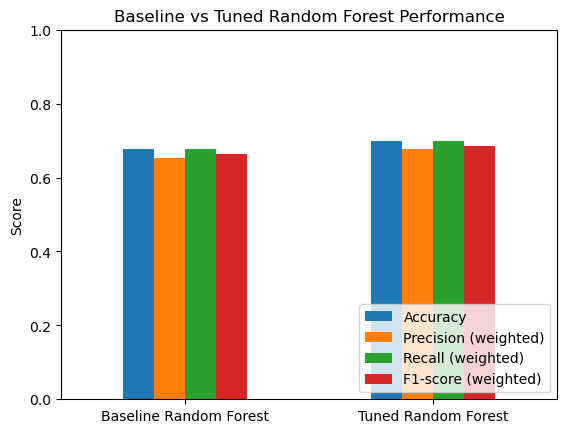

In [19]:
#Bar chart comparison

comparison_df.plot(kind="bar")
plt.ylabel("Score")
plt.title("Baseline vs Tuned Random Forest Performance")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [20]:
#Feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.163403
9,sulphates,0.114519
6,total sulfur dioxide,0.106855
1,volatile acidity,0.104191
7,density,0.086660
4,chlorides,0.077263
0,fixed acidity,0.073112
8,pH,0.073064
3,residual sugar,0.071002
2,citric acid,0.067497


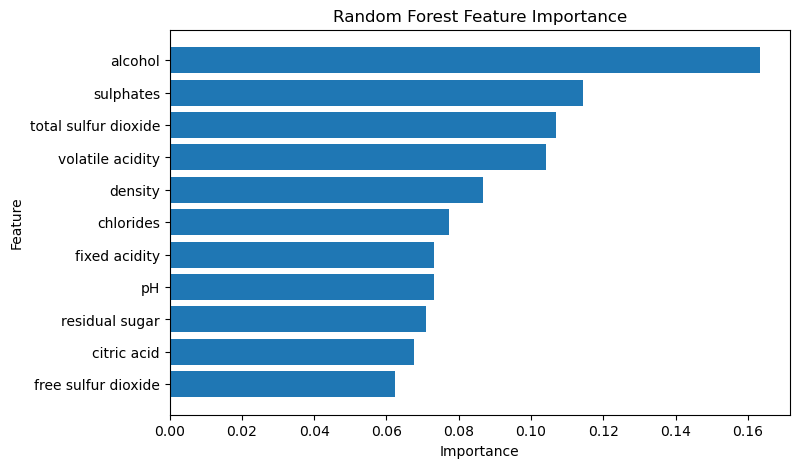

In [21]:
#Feature importance plot

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [22]:
#Save result tables

comparison_df.to_csv("random_forest_multiclass_results.csv")
feature_importance.to_csv("random_forest_feature_importance.csv", index=False)